In [65]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

# Estilo IEEE / tesis
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'figure.dpi':        150,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.5,
    'axes.linewidth':    0.8,
    'lines.linewidth':   1.2,
})
print('Imports OK ✅')

Imports OK ✅


In [66]:
# ── Figura 4.X  Escenario 1 — Porción de evaluación ──────────────────
TRAJ_FILE = 'traj_escenario1_v85.npy'
REF_FILE  = 'esc_1_4700_064_85_pinn.npy'
I_START   = 600
I_END     = 1000

traj = np.load(TRAJ_FILE, allow_pickle=True).item()
sim  = np.load(REF_FILE,  allow_pickle=True).item()

# Puntos espaciales de la ventana de evaluación (desde la sim de referencia)
x0, y0 = float(sim['x'][I_START]), float(sim['y'][I_START])
x1, y1 = float(sim['x'][I_END]),   float(sim['y'][I_END])

# Encontrar esos puntos en la trayectoria de referencia
def idx_espacial(traj, xp, yp, desde=0):
    d = np.sqrt((traj['x'][desde:] - xp)**2 + (traj['y'][desde:] - yp)**2)
    return desde + int(np.argmin(d))

i0_t = idx_espacial(traj, x0, y0)
i1_t = idx_espacial(traj, x1, y1, desde=i0_t)

print(f'Trayectoria total:  {len(traj["x"])} puntos')
print(f'Ventana evaluación: [{i0_t} → {i1_t}]  ({i1_t - i0_t} puntos)')

Trayectoria total:  195558 puntos
Ventana evaluación: [21932 → 45499]  (23567 puntos)


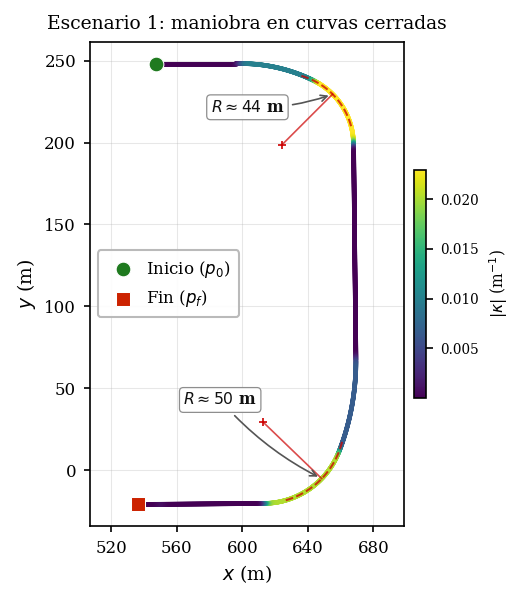

Guardado ✅


In [67]:
# ── Plot IEEE — curvatura coloreada + radios anotados ─────────────────
from matplotlib.collections import LineCollection
from scipy.signal import find_peaks

# Segmento de evaluación
x_seg   = traj['x'][i0_t:i1_t]
y_seg   = traj['y'][i0_t:i1_t]
yaw_seg = traj['yaw'][i0_t:i1_t]
k_seg   = traj['curvatura'][i0_t:i1_t]

# ── LineCollection coloreada por |κ| ──────────────────────────────────
DECIM = 8
pts  = np.array([x_seg[::DECIM], y_seg[::DECIM]]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
k_col = np.abs(k_seg[::DECIM][:-1])

lc = LineCollection(segs, cmap='viridis',
                    norm=plt.Normalize(k_col.min(), k_col.max()),
                    linewidth=2.2, zorder=3, capstyle='round')
lc.set_array(k_col)

fig, ax = plt.subplots(figsize=(3.5, 4.0))
ax.add_collection(lc)
cbar = fig.colorbar(lc, ax=ax, fraction=0.034, pad=0.03, shrink=0.85)
cbar.set_label('$|\\kappa|$ (m$^{-1}$)', fontsize=7.5)
cbar.ax.tick_params(labelsize=6.5)

# ── Picos de curvatura ─────────────────────────────────────────────────
peaks, _ = find_peaks(np.abs(k_seg),
                      height=np.percentile(np.abs(k_seg), 80),
                      distance=4000)

# Offsets (dx, dy) en metros
label_offsets = [(-52, -8), (-62, 48)]

for i_pk, pk in enumerate(peaks[:2]):
    xi, yi  = float(x_seg[pk]), float(y_seg[pk])
    ki      = float(k_seg[pk])
    Ri      = abs(1.0 / ki)
    theta_i = float(yaw_seg[pk])

    # Centro osculador
    cx = xi + np.cos(theta_i + np.pi/2) * Ri * np.sign(ki)
    cy = yi + np.sin(theta_i + np.pi/2) * Ri * np.sign(ki)

    # Arco osculador ±30°
    ang0 = np.arctan2(yi - cy, xi - cx)
    angs = np.linspace(ang0 - np.radians(30), ang0 + np.radians(30), 100)
    ax.plot(cx + Ri*np.cos(angs), cy + Ri*np.sin(angs),
            '--', color='#CC0000', linewidth=1.0, alpha=0.75, zorder=5)
    ax.plot([cx, xi], [cy, yi], '-', color='#CC0000',
            linewidth=0.8, alpha=0.7, zorder=5)
    ax.scatter(cx, cy, s=12, color='#CC0000', zorder=5, marker='+', linewidths=0.8)

    # Etiqueta dentro de la imagen
    dx, dy = label_offsets[i_pk] if i_pk < len(label_offsets) else (-40, 40)
    ax.annotate(f'$R \\approx {Ri:.0f}$ m',
                xy=(xi, yi),
                xytext=(xi + dx, yi + dy),
                fontsize=7.5, color='#111111', fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.25', fc='white',
                          ec='#888888', lw=0.6, alpha=0.95),
                arrowprops=dict(arrowstyle='->', color='#555555',
                                lw=0.8, connectionstyle='arc3,rad=0.1'),
                zorder=7)

# ── Marcadores inicio / fin ────────────────────────────────────────────
ax.scatter(x_seg[0],  y_seg[0],  s=50, color='#1F7A1F', zorder=8,
           label='Inicio ($p_0$)', marker='o', edgecolors='white', linewidths=0.5)
ax.scatter(x_seg[-1], y_seg[-1], s=50, color='#CC2200', zorder=8,
           label='Fin ($p_f$)',    marker='s', edgecolors='white', linewidths=0.5)

ax.set_xlabel('$x$ (m)', labelpad=3)
ax.set_ylabel('$y$ (m)', labelpad=3)
ax.set_title('Escenario 1: maniobra en curvas cerradas',
             fontsize=9, pad=6)
ax.set_aspect('equal', adjustable='datalim')
ax.legend(loc='center left', framealpha=0.9, edgecolor='0.7',
          handletextpad=0.4, borderpad=0.5)
ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
ax.tick_params(axis='both', which='major', length=3)

plt.tight_layout(pad=0.8)
plt.savefig('fig_esc1_trayectoria.pdf', bbox_inches='tight')
plt.savefig('fig_esc1_trayectoria.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado ✅')

In [68]:
# ── Figura Escenario 2 — Carga de datos ──────────────────────────────
TRAJ_FILE2 = 'traj_escenario2_v85.npy'
REF_FILE2  = 'esc_2_4700_064_85_pinn.npy'
I_START2   = 2900
I_END2     = None   # hasta el final

traj2 = np.load(TRAJ_FILE2, allow_pickle=True).item()
sim2  = np.load(REF_FILE2,  allow_pickle=True).item()

x0_2, y0_2 = float(sim2['x'][I_START2]), float(sim2['y'][I_START2])
x1_2 = float(sim2['x'][-1 if I_END2 is None else I_END2])
y1_2 = float(sim2['y'][-1 if I_END2 is None else I_END2])

def idx_espacial(t, xp, yp, desde=0):
    d = np.sqrt((t['x'][desde:] - xp)**2 + (t['y'][desde:] - yp)**2)
    return desde + int(np.argmin(d))

i0_t2 = idx_espacial(traj2, x0_2, y0_2)
i1_t2 = idx_espacial(traj2, x1_2, y1_2, desde=i0_t2)

print(f'Trayectoria total:  {len(traj2["x"])} puntos')
print(f'Ventana evaluación: [{i0_t2} → {i1_t2}]  ({i1_t2 - i0_t2} puntos)')

Trayectoria total:  170925 puntos
Ventana evaluación: [153520 → 170846]  (17326 puntos)


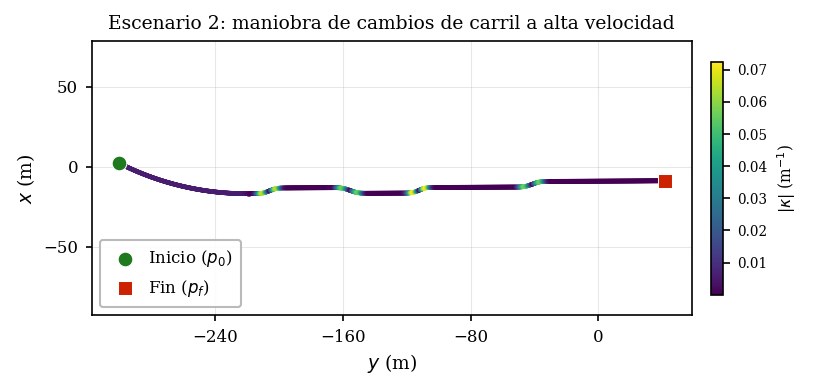

Guardado: fig_esc2_trayectoria.pdf / .png ✅


In [69]:
# ── Plot IEEE — Escenario 2: cambios de carril (horizontal) ───────────
# La trayectoria avanza en Y → ponemos Y en eje horizontal, X en vertical
from matplotlib.collections import LineCollection

x_seg2 = traj2['x'][i0_t2:i1_t2]
y_seg2 = traj2['y'][i0_t2:i1_t2]
k_seg2 = traj2['curvatura'][i0_t2:i1_t2]

DECIM2 = 8
# Swapeamos: eje horizontal = y_seg2, eje vertical = x_seg2
pts2  = np.array([y_seg2[::DECIM2], x_seg2[::DECIM2]]).T.reshape(-1, 1, 2)
segs2 = np.concatenate([pts2[:-1], pts2[1:]], axis=1)
k_col2 = np.abs(k_seg2[::DECIM2][:-1])

lc2 = LineCollection(segs2, cmap='viridis',
                     norm=plt.Normalize(k_col2.min(), k_col2.max()),
                     linewidth=2.2, zorder=3, capstyle='round')
lc2.set_array(k_col2)

fig2, ax2 = plt.subplots(figsize=(5.5, 2.6))
ax2.add_collection(lc2)
cbar2 = fig2.colorbar(lc2, ax=ax2, fraction=0.022, pad=0.03, shrink=0.85)
cbar2.set_label('$|\\kappa|$ (m$^{-1}$)', fontsize=7.5)
cbar2.ax.tick_params(labelsize=6.5)

# Marcadores (también swapeados)
ax2.scatter(y_seg2[0],  x_seg2[0],  s=50, color='#1F7A1F', zorder=8,
            label='Inicio ($p_0$)', marker='o', edgecolors='white', linewidths=0.5)
ax2.scatter(y_seg2[-1], x_seg2[-1], s=50, color='#CC2200', zorder=8,
            label='Fin ($p_f$)',    marker='s', edgecolors='white', linewidths=0.5)

ax2.set_xlabel('$y$ (m)', labelpad=3)
ax2.set_ylabel('$x$ (m)', labelpad=3)
ax2.set_title('Escenario 2: maniobra de cambios de carril a alta velocidad',
              fontsize=9, pad=6)
ax2.set_aspect('equal', adjustable='datalim')
ax2.legend(loc='lower left', framealpha=0.9, edgecolor='0.7',
           handletextpad=0.4, borderpad=0.5)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(6))
ax2.yaxis.set_major_locator(ticker.MaxNLocator(4))
ax2.tick_params(axis='both', which='major', length=3)

plt.tight_layout(pad=0.8)
plt.savefig('fig_esc2_trayectoria.pdf', bbox_inches='tight')
plt.savefig('fig_esc2_trayectoria.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_esc2_trayectoria.pdf / .png ✅')

In [70]:

# ══════════════════════════════════════════════════════════════════════
# §4.4.2  Escenario 1 — Carga de todas las configuraciones
# ══════════════════════════════════════════════════════════════════════
import os

# Puntos de anclaje espacial del segmento de evaluación
_ref = np.load('esc_1_4700_064_85_pinn.npy', allow_pickle=True).item()
_x0, _y0 = float(_ref['x'][600]),  float(_ref['y'][600])
_x1, _y1 = float(_ref['x'][1000]), float(_ref['y'][1000])

def _idx_esp(s, xp, yp, desde=0):
    d = np.sqrt((np.array(s['x'][desde:]) - xp)**2 +
                (np.array(s['y'][desde:]) - yp)**2)
    return desde + int(np.argmin(d))

# (masa_kg, mu, vel_kmh, archivo_DD, archivo_PINN)
CONFIGS_E1 = [
    (4700, 0.64, 85, 'esc_1_4700_064_85_dd.npy',       'esc_1_4700_064_85_pinn.npy'),
    (4700, 0.72, 85, 'esc_1_4700_072_85_dd.npy',       'esc_1_4700_072_85_pinn.npy'),
    (5300, 0.64, 85, 'esc_1_5300_064_85_dd.npy',       'esc_1_5300_064_85_pinn.npy'),
    (5300, 0.72, 85, 'esc_1_5300_072_85_dd.npy',       'esc_1_5300_072_85_pinn.npy'),
    (4700, 0.64, 95, 'esc_1_4700_064_95_dd.npy',       'esc_1_4700_064_95_pinn.npy'),
    (4700, 0.72, 95, 'esc_1_4700_064_95_dd.npy',       'esc_1_4700_072_95_pinn.npy'),  # proxy μ DD
    (5300, 0.64, 95, 'esc_1_5300_064_95_dd_fail.npy',  'esc_1_5300_064_95_pinn.npy'),
    (5300, 0.72, 95, 'esc_1_5300_072_95_dd.npy',       'esc_1_5300_072_95_pinn.npy'),
]

def _cargar(fname):
    if not os.path.exists(fname):
        print(f'  ⚠ No encontrado: {fname}')
        return None
    s   = np.load(fname, allow_pickle=True).item()
    i0  = _idx_esp(s, _x0, _y0)
    i1  = _idx_esp(s, _x1, _y1, desde=i0)
    cte   = np.array(s['crosstrack_error'][i0:i1], dtype=float)
    steer = np.array(s['steer_rad'][i0:i1],        dtype=float)
    spd   = np.array(s['speed'][i0:i1],            dtype=float) * 3.6
    x_v   = np.array(s['x'][i0:i1],               dtype=float)
    y_v   = np.array(s['y'][i0:i1],               dtype=float)
    ds    = np.sqrt(np.diff(x_v)**2 + np.diff(y_v)**2)
    arc   = np.concatenate([[0.0], np.cumsum(ds)])
    arc_n = arc / arc[-1] * 100 if arc[-1] > 0 else arc
    return dict(
        rmse = float(np.sqrt(np.mean(cte**2))),
        mae  = float(np.mean(np.abs(cte))),
        emax = float(np.max(np.abs(cte))),
        tvd  = float(np.sum(np.abs(np.diff(steer)))),
        vmed = float(np.mean(spd)),
        vmin = float(np.min(spd)),
        cte  = cte,
        arc_n = arc_n,
        x = x_v, y = y_v,
    )

data_dd   = [_cargar(cfg[3]) for cfg in CONFIGS_E1]
data_pinn = [_cargar(cfg[4]) for cfg in CONFIGS_E1]

print(f'\n{"Masa":>6} {"μ":>5} {"V":>5} │ {"RMSE_DD":>9} {"RMSE_PINN":>11} │ {"Emax_DD":>9} {"Emax_PINN":>11}')
print('─' * 64)
for i, cfg in enumerate(CONFIGS_E1):
    rd = data_dd[i]['rmse']   if data_dd[i]   else float('nan')
    rp = data_pinn[i]['rmse'] if data_pinn[i] else float('nan')
    ed = data_dd[i]['emax']   if data_dd[i]   else float('nan')
    ep = data_pinn[i]['emax'] if data_pinn[i] else float('nan')
    print(f'{cfg[0]:>6} {cfg[1]:>5.2f} {cfg[2]:>5} │ {rd:>9.4f} {rp:>11.4f} │ {ed:>9.4f} {ep:>11.4f}')



  Masa     μ     V │   RMSE_DD   RMSE_PINN │   Emax_DD   Emax_PINN
────────────────────────────────────────────────────────────────
  4700  0.64    85 │    0.0984      0.1887 │    0.2857      0.6194
  4700  0.72    85 │    0.0966      0.1887 │    0.2829      0.6194
  5300  0.64    85 │    0.0991      0.1544 │    0.2954      0.5250
  5300  0.72    85 │    0.0988      0.1548 │    0.2951      0.5256
  4700  0.64    95 │    0.2089      0.3814 │    0.7570      1.3341
  4700  0.72    95 │    0.2089      0.3810 │    0.7570      1.3261
  5300  0.64    95 │    0.1368      0.2205 │    0.4324      0.6294
  5300  0.72    95 │    0.1370      0.2212 │    0.4314      0.6292


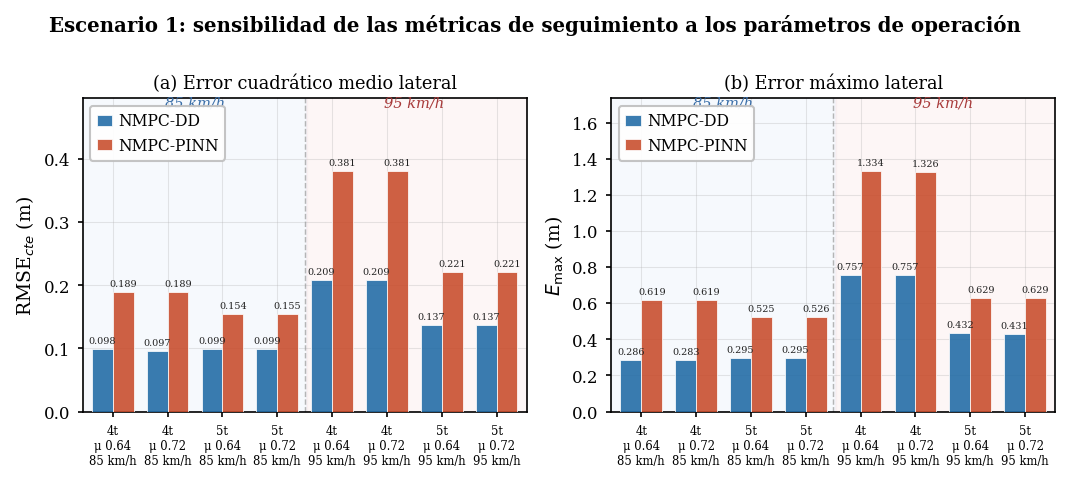

Guardado: fig_esc1_metricas_comparativa ✅


In [71]:

# ── Fig. §4.4.2 (a)  Métricas comparativas NMPC-DD vs NMPC-PINN ──────
C_DD   = '#1F6AA5'   # azul IEEE
C_PINN = '#C84B2A'   # rojo-naranja
x  = np.arange(8)
w  = 0.38

# Etiquetas compactas para eje X
xlabels = [f'{c[0]//1000}t\nμ {c[1]:.2f}\n{c[2]} km/h' for c in CONFIGS_E1]

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.1))

for ax, key, ylabel, subtitle in zip(
    axes,
    ['rmse',             'emax'],
    ['RMSE$_{cte}$ (m)', '$E_{\\mathrm{max}}$ (m)'],
    ['(a) Error cuadrático medio lateral', '(b) Error máximo lateral'],
):
    v_dd   = [d[key] if d else 0 for d in data_dd]
    v_pinn = [d[key] if d else 0 for d in data_pinn]
    ymax   = max(max(v_dd), max(v_pinn)) * 1.30

    b1 = ax.bar(x - w/2, v_dd,   w, label='NMPC-DD',   color=C_DD,
                alpha=0.88, edgecolor='white', linewidth=0.4, zorder=3)
    b2 = ax.bar(x + w/2, v_pinn, w, label='NMPC-PINN', color=C_PINN,
                alpha=0.88, edgecolor='white', linewidth=0.4, zorder=3)

    for bar, val in zip(list(b1) + list(b2), v_dd + v_pinn):
        ax.text(bar.get_x() + bar.get_width() / 2, val + ymax * 0.012,
                f'{val:.3f}', ha='center', va='bottom', fontsize=4.6, color='#222')

    # Separador visual entre grupos de velocidad
    ax.axvspan(-0.55, 3.55, color='#E8F0FB', alpha=0.35, zorder=1)
    ax.axvspan(3.55, 7.55,  color='#FBE8E8', alpha=0.35, zorder=1)
    ax.axvline(3.5, color='#999', linewidth=0.7, linestyle='--', alpha=0.7, zorder=2)
    ax.text(1.5, ymax * 0.975, '85 km/h', ha='center', fontsize=7.0,
            color='#3A6EA8', style='italic')
    ax.text(5.5, ymax * 0.975, '95 km/h', ha='center', fontsize=7.0,
            color='#A83A3A', style='italic')

    ax.set_ylabel(ylabel, labelpad=3)
    ax.set_title(subtitle, fontsize=8.5, pad=5)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=5.6)
    ax.set_xlim(-0.55, 7.55)
    ax.set_ylim(0, ymax)
    ax.legend(fontsize=7.5, framealpha=0.92, edgecolor='0.75',
              handlelength=1.0, handletextpad=0.4, loc='upper left')
    ax.tick_params(axis='both', which='major', length=2.5)

fig.suptitle(
    'Escenario 1: sensibilidad de las métricas de seguimiento a los parámetros de operación',
    fontsize=9.5, fontweight='bold', y=1.01
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_esc1_metricas_comparativa.pdf', bbox_inches='tight')
plt.savefig('fig_esc1_metricas_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_esc1_metricas_comparativa ✅')


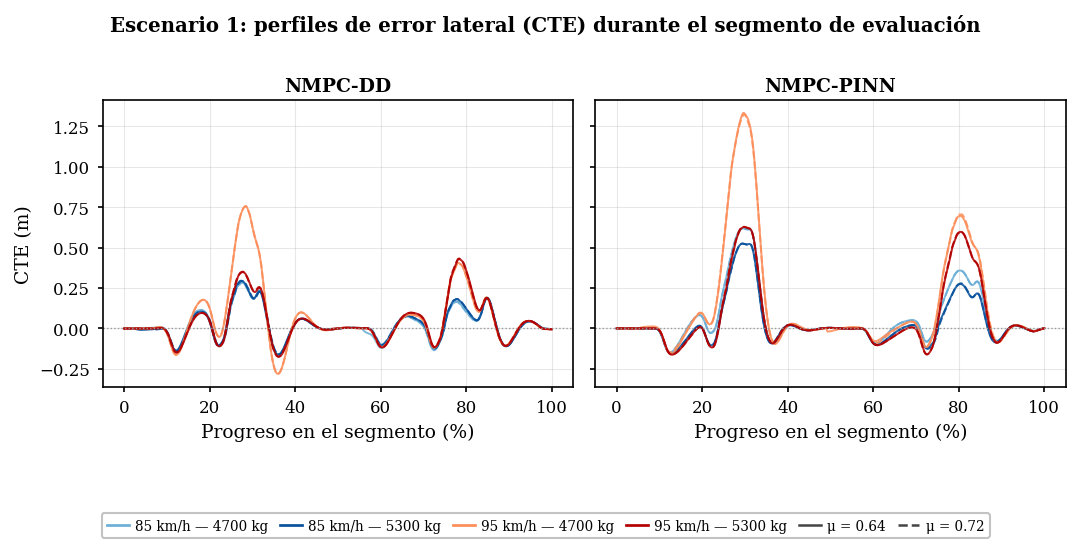

Guardado: fig_esc1_cte_comparativa ✅


In [72]:

# ── Fig. §4.4.2 (b)  Perfiles CTE — NMPC-DD vs NMPC-PINN ─────────────
from matplotlib.lines import Line2D

# Codificación visual: tono=velocidad×masa, trazo=fricción
CLR = {
    (85, 4700): '#6BAED6',   # azul claro
    (85, 5300): '#08519C',   # azul oscuro
    (95, 4700): '#FC8D59',   # naranja
    (95, 5300): '#B30000',   # rojo oscuro
}
LS = {0.64: '-', 0.72: '--'}
LW = 0.95

fig, (ax_dd, ax_pinn) = plt.subplots(1, 2, figsize=(7.16, 2.9),
                                      sharey=True, sharex=False)

for ax, data_list, ctrl_lbl in [
    (ax_dd,   data_dd,   'NMPC-DD'),
    (ax_pinn, data_pinn, 'NMPC-PINN'),
]:
    for i, cfg in enumerate(CONFIGS_E1):
        d = data_list[i]
        if d is None:
            continue
        ax.plot(d['arc_n'], d['cte'],
                color=CLR[(cfg[2], cfg[0])],
                linestyle=LS[cfg[1]],
                linewidth=LW, alpha=0.87)

    ax.axhline(0, color='#999', linewidth=0.65, linestyle=':', zorder=2)
    ax.set_xlabel('Progreso en el segmento (%)', labelpad=3)
    ax.set_title(ctrl_lbl, fontsize=9, fontweight='bold', pad=4)
    ax.tick_params(axis='both', which='major', length=2.5)

ax_dd.set_ylabel('CTE (m)', labelpad=3)

# Leyenda unificada inferior
leg_handles = [
    Line2D([0],[0], color=CLR[(85,4700)], lw=1.3, label='85 km/h — 4700 kg'),
    Line2D([0],[0], color=CLR[(85,5300)], lw=1.3, label='85 km/h — 5300 kg'),
    Line2D([0],[0], color=CLR[(95,4700)], lw=1.3, label='95 km/h — 4700 kg'),
    Line2D([0],[0], color=CLR[(95,5300)], lw=1.3, label='95 km/h — 5300 kg'),
    Line2D([0],[0], color='#444', lw=1.2, linestyle='-',  label='μ = 0.64'),
    Line2D([0],[0], color='#444', lw=1.2, linestyle='--', label='μ = 0.72'),
]
fig.legend(handles=leg_handles, loc='lower center', ncol=6,
           fontsize=6.5, framealpha=0.93, edgecolor='0.75',
           bbox_to_anchor=(0.5, -0.20),
           handlelength=1.6, columnspacing=0.9, handletextpad=0.45)

fig.suptitle(
    'Escenario 1: perfiles de error lateral (CTE) durante el segmento de evaluación',
    fontsize=9.5, fontweight='bold', y=1.02
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_esc1_cte_comparativa.pdf', bbox_inches='tight')
plt.savefig('fig_esc1_cte_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_esc1_cte_comparativa ✅')


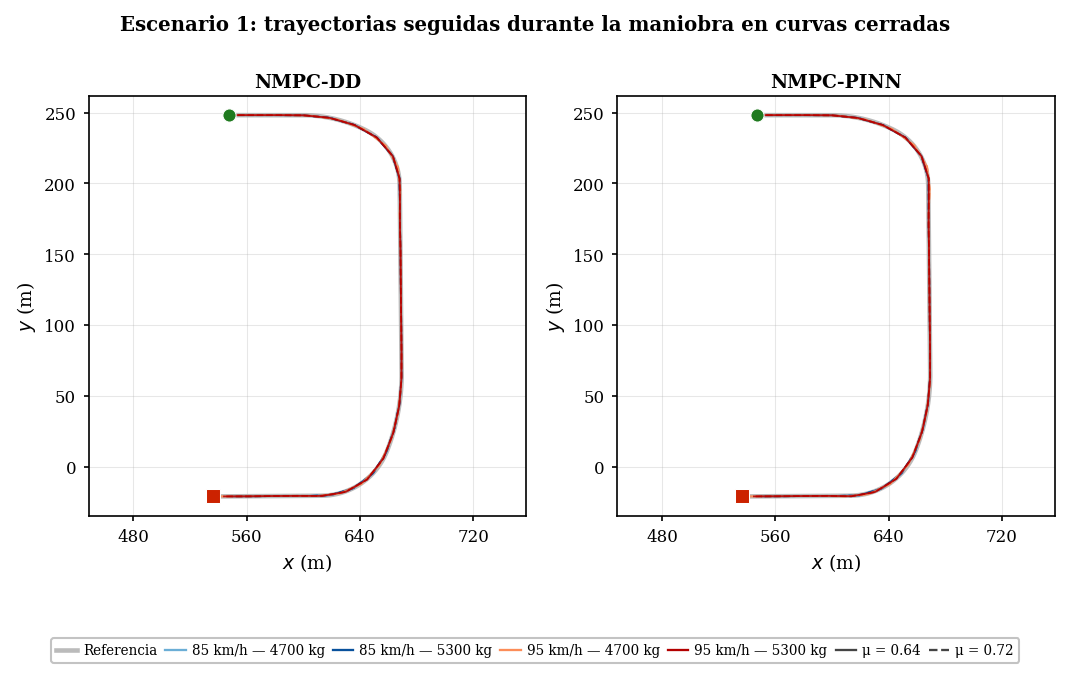

Guardado: fig_esc1_trayectoria_comparativa ✅


In [73]:

# ── Fig. §4.4.2 (c)  Trayectorias seguidas — NMPC-DD vs NMPC-PINN ────
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

DECIM_T = 15

# Segmento de referencia (variables de cell-02: traj, i0_t, i1_t)
x_ref_s = traj['x'][i0_t:i1_t:DECIM_T]
y_ref_s = traj['y'][i0_t:i1_t:DECIM_T]

CLR = {
    (85, 4700): '#6BAED6',
    (85, 5300): '#08519C',
    (95, 4700): '#FC8D59',
    (95, 5300): '#B30000',
}
LS = {0.64: '-', 0.72: '--'}

fig, (ax_dd, ax_pinn) = plt.subplots(1, 2, figsize=(7.16, 3.8),
                                      sharex=False, sharey=False)

for ax, data_list, ctrl_lbl in [
    (ax_dd,   data_dd,   'NMPC-DD'),
    (ax_pinn, data_pinn, 'NMPC-PINN'),
]:
    # Trayectoria de referencia
    ax.plot(x_ref_s, y_ref_s,
            color='#BBBBBB', linewidth=2.2, zorder=1,
            solid_capstyle='round', label='Referencia')

    for i, cfg in enumerate(CONFIGS_E1):
        d = data_list[i]
        if d is None:
            continue
        ax.plot(d['x'][::DECIM_T], d['y'][::DECIM_T],
                color=CLR[(cfg[2], cfg[0])],
                linestyle=LS[cfg[1]],
                linewidth=0.85, alpha=0.85, zorder=3)

    # Marcadores inicio / fin sobre la referencia
    ax.scatter(x_ref_s[0],  y_ref_s[0],  s=40, color='#1F7A1F',
               zorder=8, marker='o', edgecolors='white', linewidths=0.5)
    ax.scatter(x_ref_s[-1], y_ref_s[-1], s=40, color='#CC2200',
               zorder=8, marker='s', edgecolors='white', linewidths=0.5)

    ax.set_xlabel('$x$ (m)', labelpad=3)
    ax.set_ylabel('$y$ (m)', labelpad=3)
    ax.set_title(ctrl_lbl, fontsize=9, fontweight='bold', pad=4)
    ax.set_aspect('equal', adjustable='datalim')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
    ax.tick_params(axis='both', which='major', length=2.5)

# Leyenda unificada
leg_t = [
    Line2D([0],[0], color='#BBBBBB', lw=2.2, label='Referencia'),
    Line2D([0],[0], color=CLR[(85,4700)], lw=1.1, label='85 km/h — 4700 kg'),
    Line2D([0],[0], color=CLR[(85,5300)], lw=1.1, label='85 km/h — 5300 kg'),
    Line2D([0],[0], color=CLR[(95,4700)], lw=1.1, label='95 km/h — 4700 kg'),
    Line2D([0],[0], color=CLR[(95,5300)], lw=1.1, label='95 km/h — 5300 kg'),
    Line2D([0],[0], color='#444', lw=1.1, linestyle='-',  label='μ = 0.64'),
    Line2D([0],[0], color='#444', lw=1.1, linestyle='--', label='μ = 0.72'),
]
fig.legend(handles=leg_t, loc='lower center', ncol=7,
           fontsize=6.5, framealpha=0.93, edgecolor='0.75',
           bbox_to_anchor=(0.5, -0.14),
           handlelength=1.5, columnspacing=0.6, handletextpad=0.45)

fig.suptitle(
    'Escenario 1: trayectorias seguidas durante la maniobra en curvas cerradas',
    fontsize=9.5, fontweight='bold', y=1.01
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_esc1_trayectoria_comparativa.pdf', bbox_inches='tight')
plt.savefig('fig_esc1_trayectoria_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_esc1_trayectoria_comparativa ✅')


In [74]:

# ══════════════════════════════════════════════════════════════════════
# §4.4.3  Escenario 2 — Carga de todas las configuraciones
# ══════════════════════════════════════════════════════════════════════
import os

# Puntos de anclaje espacial: desde índice 2900 hasta el final
_ref2  = np.load('esc_2_4700_064_85_pinn.npy', allow_pickle=True).item()
_x0_2, _y0_2 = float(_ref2['x'][2900]), float(_ref2['y'][2900])
_x1_2, _y1_2 = float(_ref2['x'][-1]),   float(_ref2['y'][-1])

def _idx_esp2(s, xp, yp, desde=0):
    d = np.sqrt((np.array(s['x'][desde:]) - xp)**2 +
                (np.array(s['y'][desde:]) - yp)**2)
    return desde + int(np.argmin(d))

# (masa_kg, mu, vel_kmh, archivo_DD, archivo_PINN)
CONFIGS_E2 = [
    (4700, 0.64, 85, 'esc_2_4700_064_85_dd.npy',  'esc_2_4700_064_85_pinn.npy'),
    (4700, 0.72, 85, 'esc_2_4700_072_85_dd.npy',  'esc_2_4700_072_85_pinn.npy'),
    (5300, 0.64, 85, 'esc_2_5300_064_85_dd.npy',  'esc_2_5300_064_85_pinn.npy'),
    (5300, 0.72, 85, 'esc_2_5300_072_85_dd.npy',  'esc_2_5300_072_85_pinn.npy'),
    (4700, 0.64, 95, 'esc_2_4700_064_95_dd.npy',  'esc_2_4700_064_95_pinn.npy'),
    (4700, 0.72, 95, 'esc_2_4700_072_95_dd.npy',  'esc_2_4700_072_95_pinn.npy'),
    (5300, 0.64, 95, 'esc_2_5300_064_95_dd.npy',  'esc_2_5300_064_95_pinn.npy'),
    (5300, 0.72, 95, 'esc_2_5300_072_95_dd.npy',  'esc_2_5300_072_95_pinn.npy'),
]

def _cargar2(fname):
    if not os.path.exists(fname):
        print(f'  ⚠ No encontrado: {fname}')
        return None
    s   = np.load(fname, allow_pickle=True).item()
    i0  = _idx_esp2(s, _x0_2, _y0_2)
    i1  = _idx_esp2(s, _x1_2, _y1_2, desde=i0)
    cte   = np.array(s['crosstrack_error'][i0:i1], dtype=float)
    steer = np.array(s['steer_rad'][i0:i1],        dtype=float)
    spd   = np.array(s['speed'][i0:i1],            dtype=float) * 3.6
    x_v   = np.array(s['x'][i0:i1],               dtype=float)
    y_v   = np.array(s['y'][i0:i1],               dtype=float)
    ds    = np.sqrt(np.diff(x_v)**2 + np.diff(y_v)**2)
    arc   = np.concatenate([[0.0], np.cumsum(ds)])
    arc_n = arc / arc[-1] * 100 if arc[-1] > 0 else arc
    return dict(
        rmse = float(np.sqrt(np.mean(cte**2))),
        mae  = float(np.mean(np.abs(cte))),
        emax = float(np.max(np.abs(cte))),
        tvd  = float(np.sum(np.abs(np.diff(steer)))),
        vmed = float(np.mean(spd)),
        vmin = float(np.min(spd)),
        cte  = cte,
        arc_n = arc_n,
        x = x_v, y = y_v,
    )

data_dd2   = [_cargar2(cfg[3]) for cfg in CONFIGS_E2]
data_pinn2 = [_cargar2(cfg[4]) for cfg in CONFIGS_E2]

print(f'\n{"Masa":>6} {"μ":>5} {"V":>5} │ {"RMSE_DD":>9} {"RMSE_PINN":>11} │ {"Emax_DD":>9} {"Emax_PINN":>11}')
print('─' * 64)
for i, cfg in enumerate(CONFIGS_E2):
    rd = data_dd2[i]['rmse']   if data_dd2[i]   else float('nan')
    rp = data_pinn2[i]['rmse'] if data_pinn2[i] else float('nan')
    ed = data_dd2[i]['emax']   if data_dd2[i]   else float('nan')
    ep = data_pinn2[i]['emax'] if data_pinn2[i] else float('nan')
    print(f'{cfg[0]:>6} {cfg[1]:>5.2f} {cfg[2]:>5} │ {rd:>9.4f} {rp:>11.4f} │ {ed:>9.4f} {ep:>11.4f}')



  Masa     μ     V │   RMSE_DD   RMSE_PINN │   Emax_DD   Emax_PINN
────────────────────────────────────────────────────────────────
  4700  0.64    85 │    0.2927      0.2937 │    0.7832      0.9637
  4700  0.72    85 │    0.2927      0.2935 │    0.7830      0.9637
  5300  0.64    85 │    0.2927      0.2902 │    0.7983      0.9124
  5300  0.72    85 │    0.2920      0.2908 │    0.7827      0.9163
  4700  0.64    95 │    0.3654      0.3254 │    0.9920      1.0872
  4700  0.72    95 │    0.3655      0.3253 │    0.9922      1.0862
  5300  0.64    95 │    0.3634      0.3270 │    0.9824      1.0269
  5300  0.72    95 │    0.3660      0.3263 │    0.9768      1.0285


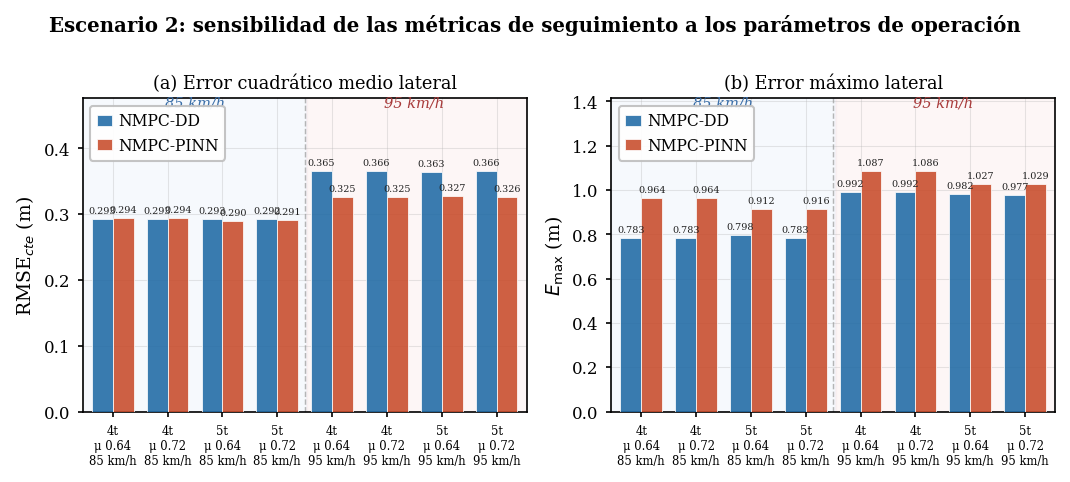

Guardado: fig_esc2_metricas_comparativa ✅


In [75]:

# ── Fig. §4.4.3 (a)  Métricas comparativas Escenario 2 ───────────────
C_DD   = '#1F6AA5'
C_PINN = '#C84B2A'
x  = np.arange(8)
w  = 0.38

xlabels2 = [f'{c[0]//1000}t\nμ {c[1]:.2f}\n{c[2]} km/h' for c in CONFIGS_E2]

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.1))

for ax, key, ylabel, subtitle in zip(
    axes,
    ['rmse',             'emax'],
    ['RMSE$_{cte}$ (m)', '$E_{\\mathrm{max}}$ (m)'],
    ['(a) Error cuadrático medio lateral', '(b) Error máximo lateral'],
):
    v_dd   = [d[key] if d else 0 for d in data_dd2]
    v_pinn = [d[key] if d else 0 for d in data_pinn2]
    ymax   = max(max(v_dd), max(v_pinn)) * 1.30

    b1 = ax.bar(x - w/2, v_dd,   w, label='NMPC-DD',   color=C_DD,
                alpha=0.88, edgecolor='white', linewidth=0.4, zorder=3)
    b2 = ax.bar(x + w/2, v_pinn, w, label='NMPC-PINN', color=C_PINN,
                alpha=0.88, edgecolor='white', linewidth=0.4, zorder=3)

    for bar, val in zip(list(b1) + list(b2), v_dd + v_pinn):
        ax.text(bar.get_x() + bar.get_width() / 2, val + ymax * 0.012,
                f'{val:.3f}', ha='center', va='bottom', fontsize=4.6, color='#222')

    ax.axvspan(-0.55, 3.55, color='#E8F0FB', alpha=0.35, zorder=1)
    ax.axvspan(3.55,  7.55, color='#FBE8E8', alpha=0.35, zorder=1)
    ax.axvline(3.5, color='#999', linewidth=0.7, linestyle='--', alpha=0.7, zorder=2)
    ax.text(1.5, ymax * 0.975, '85 km/h', ha='center', fontsize=7.0,
            color='#3A6EA8', style='italic')
    ax.text(5.5, ymax * 0.975, '95 km/h', ha='center', fontsize=7.0,
            color='#A83A3A', style='italic')

    ax.set_ylabel(ylabel, labelpad=3)
    ax.set_title(subtitle, fontsize=8.5, pad=5)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels2, fontsize=5.6)
    ax.set_xlim(-0.55, 7.55)
    ax.set_ylim(0, ymax)
    ax.legend(fontsize=7.5, framealpha=0.92, edgecolor='0.75',
              handlelength=1.0, handletextpad=0.4, loc='upper left')
    ax.tick_params(axis='both', which='major', length=2.5)

fig.suptitle(
    'Escenario 2: sensibilidad de las métricas de seguimiento a los parámetros de operación',
    fontsize=9.5, fontweight='bold', y=1.01
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_esc2_metricas_comparativa.pdf', bbox_inches='tight')
plt.savefig('fig_esc2_metricas_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_esc2_metricas_comparativa ✅')


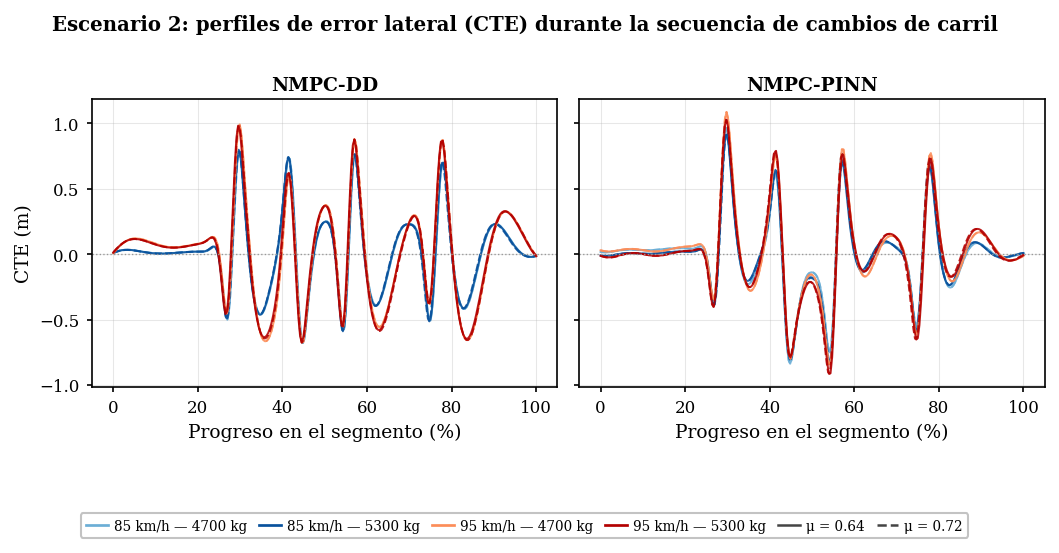

Guardado: fig_esc2_cte_comparativa ✅


In [76]:

# ── Fig. §4.4.3 (b)  Perfiles CTE — Escenario 2 ──────────────────────
from matplotlib.lines import Line2D

CLR2 = {
    (85, 4700): '#6BAED6',
    (85, 5300): '#08519C',
    (95, 4700): '#FC8D59',
    (95, 5300): '#B30000',
}
LS2 = {0.64: '-', 0.72: '--'}
LW2 = 0.95

fig, (ax_dd, ax_pinn) = plt.subplots(1, 2, figsize=(7.16, 2.9),
                                      sharey=True, sharex=False)

for ax, data_list, ctrl_lbl in [
    (ax_dd,   data_dd2,   'NMPC-DD'),
    (ax_pinn, data_pinn2, 'NMPC-PINN'),
]:
    for i, cfg in enumerate(CONFIGS_E2):
        d = data_list[i]
        if d is None:
            continue
        ax.plot(d['arc_n'], d['cte'],
                color=CLR2[(cfg[2], cfg[0])],
                linestyle=LS2[cfg[1]],
                linewidth=LW2, alpha=0.87)

    ax.axhline(0, color='#999', linewidth=0.65, linestyle=':', zorder=2)
    ax.set_xlabel('Progreso en el segmento (%)', labelpad=3)
    ax.set_title(ctrl_lbl, fontsize=9, fontweight='bold', pad=4)
    ax.tick_params(axis='both', which='major', length=2.5)

ax_dd.set_ylabel('CTE (m)', labelpad=3)

leg_handles2 = [
    Line2D([0],[0], color=CLR2[(85,4700)], lw=1.3, label='85 km/h — 4700 kg'),
    Line2D([0],[0], color=CLR2[(85,5300)], lw=1.3, label='85 km/h — 5300 kg'),
    Line2D([0],[0], color=CLR2[(95,4700)], lw=1.3, label='95 km/h — 4700 kg'),
    Line2D([0],[0], color=CLR2[(95,5300)], lw=1.3, label='95 km/h — 5300 kg'),
    Line2D([0],[0], color='#444', lw=1.2, linestyle='-',  label='μ = 0.64'),
    Line2D([0],[0], color='#444', lw=1.2, linestyle='--', label='μ = 0.72'),
]
fig.legend(handles=leg_handles2, loc='lower center', ncol=6,
           fontsize=6.5, framealpha=0.93, edgecolor='0.75',
           bbox_to_anchor=(0.5, -0.20),
           handlelength=1.6, columnspacing=0.9, handletextpad=0.45)

fig.suptitle(
    'Escenario 2: perfiles de error lateral (CTE) durante la secuencia de cambios de carril',
    fontsize=9.5, fontweight='bold', y=1.02
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_esc2_cte_comparativa.pdf', bbox_inches='tight')
plt.savefig('fig_esc2_cte_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_esc2_cte_comparativa ✅')


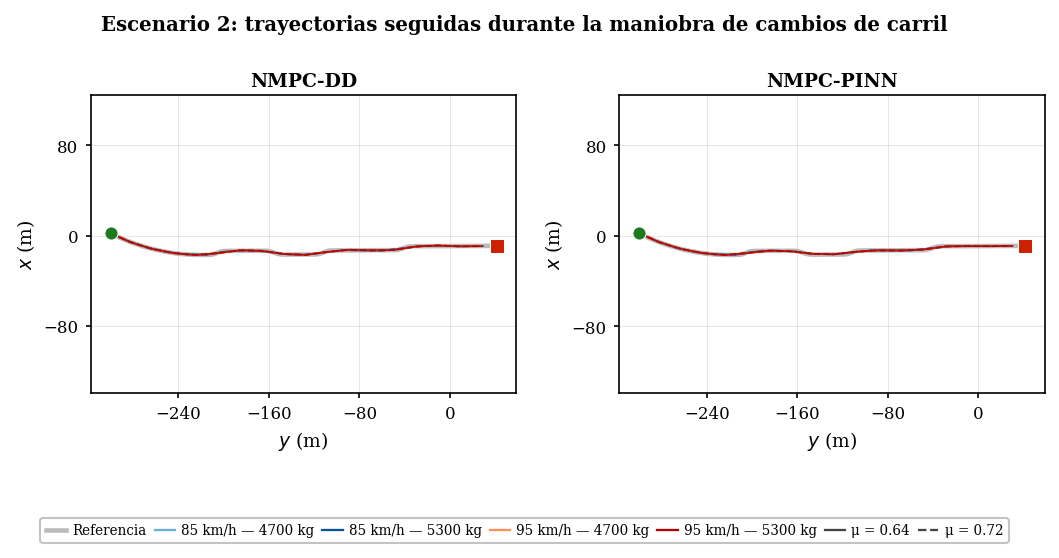

Guardado: fig_esc2_trayectoria_comparativa ✅


In [77]:

# ── Fig. §4.4.3 (c)  Trayectorias seguidas — Escenario 2 ─────────────
# La trayectoria avanza en Y → eje horizontal = Y, eje vertical = X
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

DECIM_T2 = 15

# Segmento de referencia (variables de cell 9f628005: traj2, i0_t2, i1_t2)
x_ref_s2 = traj2['x'][i0_t2:i1_t2:DECIM_T2]
y_ref_s2 = traj2['y'][i0_t2:i1_t2:DECIM_T2]

CLR2 = {
    (85, 4700): '#6BAED6',
    (85, 5300): '#08519C',
    (95, 4700): '#FC8D59',
    (95, 5300): '#B30000',
}
LS2 = {0.64: '-', 0.72: '--'}

fig, (ax_dd, ax_pinn) = plt.subplots(1, 2, figsize=(7.16, 3.0),
                                      sharex=False, sharey=False)

for ax, data_list, ctrl_lbl in [
    (ax_dd,   data_dd2,   'NMPC-DD'),
    (ax_pinn, data_pinn2, 'NMPC-PINN'),
]:
    # Referencia (Y horizontal, X vertical — mismo criterio que fig_esc2_trayectoria)
    ax.plot(y_ref_s2, x_ref_s2,
            color='#BBBBBB', linewidth=2.2, zorder=1, solid_capstyle='round')

    for i, cfg in enumerate(CONFIGS_E2):
        d = data_list[i]
        if d is None:
            continue
        ax.plot(d['y'][::DECIM_T2], d['x'][::DECIM_T2],
                color=CLR2[(cfg[2], cfg[0])],
                linestyle=LS2[cfg[1]],
                linewidth=0.85, alpha=0.85, zorder=3)

    # Marcadores inicio / fin
    ax.scatter(y_ref_s2[0],  x_ref_s2[0],  s=40, color='#1F7A1F',
               zorder=8, marker='o', edgecolors='white', linewidths=0.5)
    ax.scatter(y_ref_s2[-1], x_ref_s2[-1], s=40, color='#CC2200',
               zorder=8, marker='s', edgecolors='white', linewidths=0.5)

    ax.set_xlabel('$y$ (m)', labelpad=3)
    ax.set_ylabel('$x$ (m)', labelpad=3)
    ax.set_title(ctrl_lbl, fontsize=9, fontweight='bold', pad=4)
    ax.set_aspect('equal', adjustable='datalim')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.tick_params(axis='both', which='major', length=2.5)

# Leyenda unificada
leg_t2 = [
    Line2D([0],[0], color='#BBBBBB', lw=2.2,  label='Referencia'),
    Line2D([0],[0], color=CLR2[(85,4700)], lw=1.1, label='85 km/h — 4700 kg'),
    Line2D([0],[0], color=CLR2[(85,5300)], lw=1.1, label='85 km/h — 5300 kg'),
    Line2D([0],[0], color=CLR2[(95,4700)], lw=1.1, label='95 km/h — 4700 kg'),
    Line2D([0],[0], color=CLR2[(95,5300)], lw=1.1, label='95 km/h — 5300 kg'),
    Line2D([0],[0], color='#444', lw=1.1, linestyle='-',  label='μ = 0.64'),
    Line2D([0],[0], color='#444', lw=1.1, linestyle='--', label='μ = 0.72'),
]
fig.legend(handles=leg_t2, loc='lower center', ncol=7,
           fontsize=6.5, framealpha=0.93, edgecolor='0.75',
           bbox_to_anchor=(0.5, -0.18),
           handlelength=1.5, columnspacing=0.6, handletextpad=0.45)

fig.suptitle(
    'Escenario 2: trayectorias seguidas durante la maniobra de cambios de carril',
    fontsize=9.5, fontweight='bold', y=1.01
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_esc2_trayectoria_comparativa.pdf', bbox_inches='tight')
plt.savefig('fig_esc2_trayectoria_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_esc2_trayectoria_comparativa ✅')


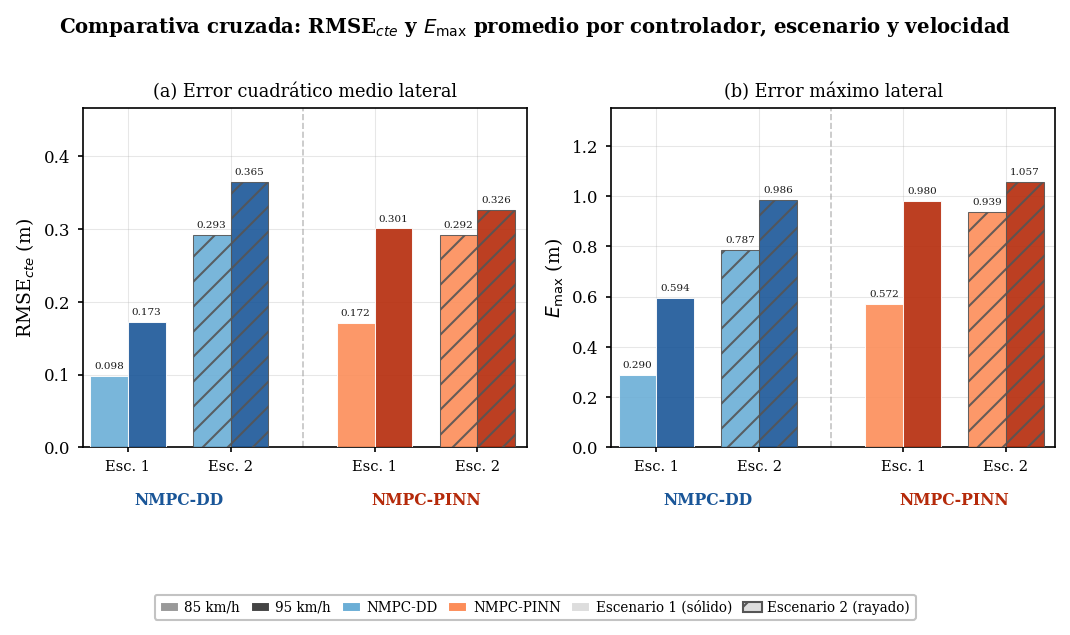

Guardado: fig_comparativa_cruzada ✅


In [78]:

# ══════════════════════════════════════════════════════════════════════
# §4.4.4  Comparativa cruzada — ambos escenarios y controladores
# ══════════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as ticker

# ── Promedios sobre masa×fricción (índices 0:4 = 85 km/h, 4:8 = 95 km/h)
def _avg(data_list, idx_range, key):
    vals = [data_list[i][key] for i in idx_range if data_list[i] is not None]
    return float(np.mean(vals))

avgs = {}
for key in ['rmse', 'emax']:
    avgs[key] = {
        ('E1', 'DD',   85): _avg(data_dd,    range(0, 4), key),
        ('E1', 'DD',   95): _avg(data_dd,    range(4, 8), key),
        ('E1', 'PINN', 85): _avg(data_pinn,  range(0, 4), key),
        ('E1', 'PINN', 95): _avg(data_pinn,  range(4, 8), key),
        ('E2', 'DD',   85): _avg(data_dd2,   range(0, 4), key),
        ('E2', 'DD',   95): _avg(data_dd2,   range(4, 8), key),
        ('E2', 'PINN', 85): _avg(data_pinn2, range(0, 4), key),
        ('E2', 'PINN', 95): _avg(data_pinn2, range(4, 8), key),
    }

# ── Layout de barras ───────────────────────────────────────────────────
GRP_POS    = [0.0, 1.25, 3.0, 4.25]
GRP_COMBOS = [('E1','DD'), ('E2','DD'), ('E1','PINN'), ('E2','PINN')]
GRP_XLBL   = ['Esc. 1',   'Esc. 2',   'Esc. 1',      'Esc. 2']

C_DD_85   = '#6BAED6'
C_DD_95   = '#1A5698'
C_PINN_85 = '#FC8D59'
C_PINN_95 = '#B52A0A'
W = 0.46

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.4))

for ax, key, ylabel, subtitle in zip(
    axes,
    ['rmse',             'emax'],
    ['RMSE$_{cte}$ (m)', '$E_{\\mathrm{max}}$ (m)'],
    ['(a) Error cuadrático medio lateral', '(b) Error máximo lateral'],
):
    all_vals = [avgs[key][(e, c, v)] for (e,c) in GRP_COMBOS for v in (85,95)]
    ymax = max(all_vals) * 1.28

    for pos, (esc, ctrl) in zip(GRP_POS, GRP_COMBOS):
        c85   = C_DD_85   if ctrl == 'DD' else C_PINN_85
        c95   = C_DD_95   if ctrl == 'DD' else C_PINN_95
        hatch = None if esc == 'E1' else '//'
        ec    = 'white'   if esc == 'E1' else '#555555'

        v85 = avgs[key][(esc, ctrl, 85)]
        v95 = avgs[key][(esc, ctrl, 95)]

        b1 = ax.bar(pos - W/2, v85, W, color=c85, alpha=0.90,
                    edgecolor=ec, linewidth=0.5, hatch=hatch, zorder=3)
        b2 = ax.bar(pos + W/2, v95, W, color=c95, alpha=0.90,
                    edgecolor=ec, linewidth=0.5, hatch=hatch, zorder=3)

        # Etiquetas de valor
        for bar, val in [(b1, v85), (b2, v95)]:
            ax.text(bar[0].get_x() + bar[0].get_width()/2,
                    val + ymax * 0.015,
                    f'{val:.3f}', ha='center', va='bottom',
                    fontsize=5.0, color='#1a1a1a')

    # ── Separador visual DD | PINN ────────────────────────────────────
    ax.axvline(2.125, color='#aaa', linewidth=0.8, linestyle='--', alpha=0.7, zorder=2)

    # Etiquetas de controlador bajo el eje X
    ax.text(0.625, -ymax * 0.17, 'NMPC-DD', ha='center',
            fontsize=7.5, fontweight='bold', color='#1A5698')
    ax.text(3.625, -ymax * 0.17, 'NMPC-PINN', ha='center',
            fontsize=7.5, fontweight='bold', color='#B52A0A')

    ax.set_xticks(GRP_POS)
    ax.set_xticklabels(GRP_XLBL, fontsize=7.0)
    ax.set_xlim(-0.55, 4.85)
    ax.set_ylim(0, ymax)
    ax.set_ylabel(ylabel, labelpad=3)
    ax.set_title(subtitle, fontsize=8.5, pad=5)
    ax.tick_params(axis='both', which='major', length=2.5)

# ── Leyenda unificada ──────────────────────────────────────────────────
leg_items = [
    Patch(facecolor='#999', edgecolor='white', label='85 km/h'),
    Patch(facecolor='#444', edgecolor='white', label='95 km/h'),
    Patch(facecolor='#6BAED6', edgecolor='white', label='NMPC-DD'),
    Patch(facecolor='#FC8D59', edgecolor='white', label='NMPC-PINN'),
    Patch(facecolor='#ddd', edgecolor='white',   hatch=None,  label='Escenario 1 (sólido)'),
    Patch(facecolor='#ddd', edgecolor='#555555', hatch='//',  label='Escenario 2 (rayado)'),
]
fig.legend(handles=leg_items, loc='lower center', ncol=6,
           fontsize=6.5, framealpha=0.93, edgecolor='0.75',
           bbox_to_anchor=(0.5, -0.18),
           handlelength=1.4, columnspacing=0.8, handletextpad=0.4)

fig.suptitle(
    'Comparativa cruzada: RMSE$_{cte}$ y $E_{\\mathrm{max}}$ promedio por controlador, escenario y velocidad',
    fontsize=9.5, fontweight='bold', y=1.02
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_comparativa_cruzada.pdf', bbox_inches='tight')
plt.savefig('fig_comparativa_cruzada.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_comparativa_cruzada ✅')
